In [1]:
import os
import sys
import numpy as np
import pandas as pd

project_root = r"C:\Users\Arafat\Desktop\IMA Project"
if project_root not in sys.path:
    sys.path.append(project_root)

from src import config
from src import pipelines
from src.knn import MyKNNClassifier
from src import evaluation
from src import visualization
from src.utils import set_random_seed
from sklearn.preprocessing import StandardScaler

config.make_all_dirs()
set_random_seed(42)

print("All pipelines defined:")
for k, v in pipelines.PIPELINES.items():
    print("-", k, ":", v["description"])


[utils] Random seed set to 42
All pipelines defined:
- RawPixels : Simple baseline using raw grayscale pixel values.
- GrayHist : Grayscale intensity histogram only.
- ColorHists : Color histograms in RGB and HSV.
- Texture_LBP_GLCM : Texture features using LBP and GLCM.
- EdgesAndTexture : Gradient info (Sobel hist) + texture (LBP).
- Frequency_FFT_DCT : Frequency features using FFT radial + DCT low block.
- Morphology_GrayHist : Shape features from morphology + gray histogram.
- Combo_BestGuess : Combination of gray hist, LBP, Sobel, FFT radial.


### function to load & scale features

In [2]:
def load_and_scale_features(pipe_name: str):
    pipe_folder = os.path.join(config.FEATURES_DIR, pipe_name)
    npz_path = os.path.join(pipe_folder, f"{pipe_name}_features.npz")
    print("Loading features from:", npz_path)
    data = np.load(npz_path)

    feat_train = data["feat_train"]
    feat_val = data["feat_val"]
    feat_test = data["feat_test"]
    y_train = data["y_train"]
    y_val = data["y_val"]
    y_test = data["y_test"]

    scaler = StandardScaler()
    feat_train_scaled = scaler.fit_transform(feat_train)
    feat_val_scaled = scaler.transform(feat_val)
    feat_test_scaled = scaler.transform(feat_test)

    return feat_train_scaled, feat_val_scaled, feat_test_scaled, y_train, y_val, y_test


### choosing list of pipelines and k values to test

In [4]:
# here I choose more pipelines, including combinations

experiment_pipelines = [
    "RawPixels",
    "GrayHist",
    "ColorHists",
    "Texture_LBP_GLCM",
    "EdgesAndTexture",
    "Frequency_FFT_DCT",
    "Morphology_GrayHist",
    "Combo_BestGuess",
]

k_list = [1, 3, 5, 7, 9]

print("Pipelines to test:", experiment_pipelines)
print("k values:", k_list)


Pipelines to test: ['RawPixels', 'GrayHist', 'ColorHists', 'Texture_LBP_GLCM', 'EdgesAndTexture', 'Frequency_FFT_DCT', 'Morphology_GrayHist', 'Combo_BestGuess']
k values: [1, 3, 5, 7, 9]


### running validation experiments and collect results

In [5]:
all_results = []

for pipe_name in experiment_pipelines:
    print("\n========================================")
    print("Pipeline:", pipe_name)
    feat_train, feat_val, feat_test, y_train, y_val, y_test = load_and_scale_features(pipe_name)

    for k_value in k_list:
        print(f"\n[MyKNN] pipeline={pipe_name}, k={k_value}")
        my_knn = MyKNNClassifier(k_value=k_value, distance_metric="l2", use_distance_weight=False)
        my_knn.fit(feat_train, y_train)
        y_val_pred = my_knn.predict(feat_val)

        metrics_dict = evaluation.compute_basic_metrics(y_val, y_val_pred)
        metrics_dict["pipeline"] = pipe_name
        metrics_dict["k_value"] = k_value
        all_results.append(metrics_dict)

df_val_results = pd.DataFrame(all_results)
print("Validation results summary:")
df_val_results.head()



Pipeline: RawPixels
Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\RawPixels\RawPixels_features.npz

[MyKNN] pipeline=RawPixels, k=1
[MyKNN] Stored training data with shape: (7466, 16384)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Predicted 350/2489 samples
[MyKNN] Predicted 400/2489 samples
[MyKNN] Predicted 450/2489 samples
[MyKNN] Predicted 500/2489 samples
[MyKNN] Predicted 550/2489 samples
[MyKNN] Predicted 600/2489 samples
[MyKNN] Predicted 650/2489 samples
[MyKNN] Predicted 700/2489 samples
[MyKNN] Predicted 750/2489 samples
[MyKNN] Predicted 800/2489 samples
[MyKNN] Predicted 850/2489 samples
[MyKNN] Predicted 900/2489 samples
[MyKNN] Predicted 950/2489 samples
[MyKNN] Predicted 1000/2489 samples
[MyKNN] Predicted 1050/2489 samples
[MyKNN] Predicted 1100/2489 samples
[My

,accuracy,macro_precision,macro_recall,macro_f1,pipeline,k_value
0,0.571716,0.577817,0.572135,0.569001,RawPixels,1
1,0.498192,0.515854,0.498469,0.495947,RawPixels,3
2,0.493773,0.507788,0.494062,0.488444,RawPixels,5
3,0.468059,0.494193,0.468237,0.464351,RawPixels,7
4,0.460024,0.488431,0.460199,0.455492,RawPixels,9


### saving validation results to CSV

In [6]:
results_folder = config.EXPERIMENT_RESULTS_DIR
if not os.path.exists(results_folder):
    os.makedirs(results_folder, exist_ok=True)

val_results_path = os.path.join(results_folder, "per_pipeline_val_results.csv")
df_val_results.to_csv(val_results_path, index=False)
print("Saved validation results to:", val_results_path)


Saved validation results to: C:\Users\Arafat\Desktop\IMA Project\experiments\results\per_pipeline_val_results.csv


### visualizing summarised accuracy per pipeline

In [7]:
plt_data = df_val_results.groupby("pipeline")["accuracy"].max().reset_index()
plt_data = plt_data.sort_values("accuracy", ascending=False)
plt_data


,pipeline,accuracy
0,ColorHists,0.964243
1,Combo_BestGuess,0.928887
4,GrayHist,0.894737
5,Morphology_GrayHist,0.861792
2,EdgesAndTexture,0.799518
7,Texture_LBP_GLCM,0.772599
6,RawPixels,0.571716
3,Frequency_FFT_DCT,0.406589


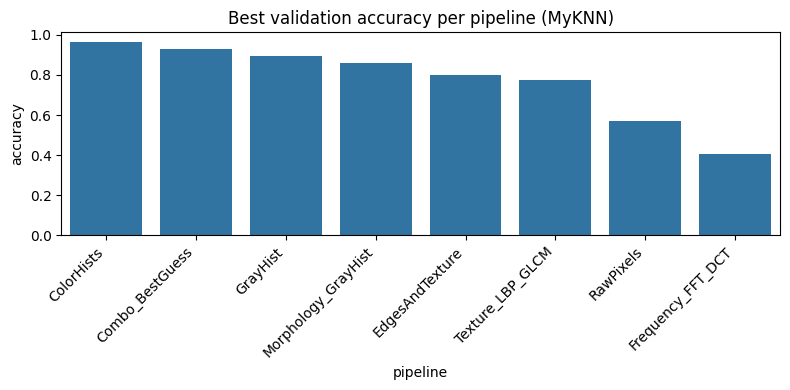

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.barplot(data=plt_data, x="pipeline", y="accuracy")
plt.xticks(rotation=45, ha="right")
plt.title("Best validation accuracy per pipeline (MyKNN)")
plt.tight_layout()
plt.show()


### picking the best pipeline + k, evaluate on test

In [9]:
# here I pick best (pipeline, k) based on validation macro_f1 and test it

idx_best = df_val_results["macro_f1"].idxmax()
best_row = df_val_results.iloc[idx_best]
print("Best config overall (val macro F1):")
print(best_row)

best_pipe = best_row["pipeline"]
best_k = int(best_row["k_value"])

print("\nNow evaluating best config on test set...")
feat_train, feat_val, feat_test, y_train, y_val, y_test = load_and_scale_features(best_pipe)

my_knn = MyKNNClassifier(k_value=best_k, distance_metric="l2", use_distance_weight=False)
my_knn.fit(np.vstack([feat_train, feat_val]), np.concatenate([y_train, y_val]))
y_test_pred = my_knn.predict(feat_test)

metrics_test = evaluation.compute_basic_metrics(y_test, y_test_pred)
print("Test metrics:", metrics_test)


Best config overall (val macro F1):
accuracy             0.964243
macro_precision      0.964391
macro_recall         0.964334
macro_f1             0.964118
pipeline           ColorHists
k_value                     1
Name: 10, dtype: object

Now evaluating best config on test set...
Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\ColorHists\ColorHists_features.npz
[MyKNN] Stored training data with shape: (9955, 96)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Predicted 350/2489 samples
[MyKNN] Predicted 400/2489 samples
[MyKNN] Predicted 450/2489 samples
[MyKNN] Predicted 500/2489 samples
[MyKNN] Predicted 550/2489 samples
[MyKNN] Predicted 600/2489 samples
[MyKNN] Predicted 650/2489 samples
[MyKNN] Predicted 700/2489 samples
[MyKNN] Predicted 750/2489 samples
[MyKNN] Predicted 800/2

### confusion matrix and classification 

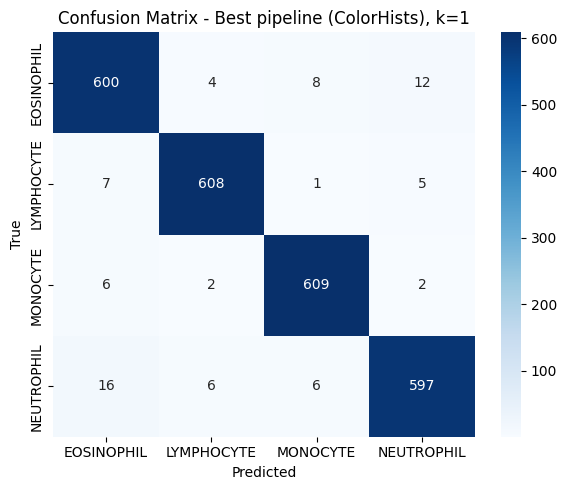

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       624
           1       0.98      0.98      0.98       621
           2       0.98      0.98      0.98       619
           3       0.97      0.96      0.96       625

    accuracy                           0.97      2489
   macro avg       0.97      0.97      0.97      2489
weighted avg       0.97      0.97      0.97      2489



In [10]:
label_map_path = os.path.join(config.PROCESSED_DATA_DIR, "label_mapping.csv")
label_map_df = pd.read_csv(label_map_path)
class_names = list(label_map_df["class_name"])

cm = evaluation.compute_confusion(y_test, y_test_pred, label_order=list(range(len(class_names))))
visualization.plot_confusion_matrix(
    cm,
    class_names=class_names,
    title=f"Confusion Matrix - Best pipeline ({best_pipe}), k={best_k}",
)

evaluation.print_detailed_classification_report(y_test, y_test_pred)
